In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('product.csv',encoding='latin-1'  )
df.head()

,product_id,product,brand,type,length,depth,width,category,sub_category.,volume
0,P0021,"Tomato - Local, Organically Grown",Fresho,Organic Vegetables,8.0,26.0,23.0,Fruits & Vegetables,Fresh Vegetables,4784.0
1,P0028,Tomato - Green,Fresho,Marigold,3.4,11.3,12.0,Fruits & Vegetables,"Flower Bouquets, Bunches",461.0
2,P0029,"Chilli - Green, Organically Grown",Fresho,"Potato, Onion & Tomato",2.5,18.0,8.0,Fruits & Vegetables,Fresh Vegetables,360.0
3,P0030,Ginger - Organically Grown,Fresho,Organic Vegetables,9.0,9.0,37.0,Fruits & Vegetables,Herbs & Seasonings,2997.0
4,P0031,"Chilli - Green, Organically Grown",Fresho,Organic Vegetables,NaN,NaN,NaN,Fruits & Vegetables,Herbs & Seasonings,NaN


In [3]:
df.shape    

(699, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     699 non-null    object 
 1   product        698 non-null    object 
 2   brand          698 non-null    object 
 3   type           699 non-null    object 
 4   length         683 non-null    float64
 5   depth          683 non-null    float64
 6   width          681 non-null    float64
 7   category       699 non-null    object 
 8   sub_category.  699 non-null    object 
 9   volume         681 non-null    float64
dtypes: float64(4), object(6)
memory usage: 54.7+ KB


In [5]:
summary = {"Mean": df['volume'].mean(), "Median": df['volume'].median(), "Mode": df['volume'].mode(),"Min": df['volume'].min(), "Max": df['volume'].max(), "Count"  : df['volume'].count()}
print("Summary Statistics for 'volume'")
for stat, value in summary.items():
    print(f"{stat}: {value}")

Summary Statistics for 'volume'
Mean: 7225.691629955947
Median: 726.0
Mode: 0    2240.0
Name: volume, dtype: float64
Min: 0.0
Max: 1600000.0
Count: 681


In [10]:
#filter rows : only show "organic vegetables"
organic_vegetables = df[df['type'] == 'organic veg']
organic_vegetables.head()
print(organic_vegetables)


Empty DataFrame
Columns: [product_id, product, brand, type, length, depth, width, category, sub_category., volume]
Index: []


In [12]:
# select specific columns
selected_columns = organic_vegetables[['product', 'category','volume']]

In [16]:
#slice rows : only show first 10 rows to 30 rows
sliced_rows = df.iloc[10:30]
print(sliced_rows)


   product_id                           product   brand  \
10      P0114                       Lemon Grass  Fresho   
11      P0128          Mint - Organically Grown  Fresho   
12      P0129                              Kale  Fresho   
13      P0130                      Tulsi Leaves  Fresho   
14      P0184                       Lemon Grass  Fresho   
15      P0187                          Cucumber  Fresho   
16      P0188                         Colocasia  Fresho   
17      P0189                        Betel Leaf  Fresho   
18      P0190     Colocasia - Organically Grown  Fresho   
19      P0192     Colocasia - Organically Grown  Fresho   
20      P0197                       Basale Leaf  Fresho   
21      P0212                       Snake Gourd  Fresho   
22      P0213       Chilli - Green Long, Medium  Fresho   
23      P0219      Coccinia - Organically Grown  Fresho   
24      P0220     Drumstick - Organically Grown  Fresho   
25      P0222  Curry Leaves - Organically Grown  Fresho 

In [17]:
selected_columns.to_csv('organic_report.csv', index=False)

In [18]:
#selected_columns.to_csv('organic_report.csv', index=False)
print("Selected columns have been saved to 'organic_report.csv'")

Selected columns have been saved to 'organic_report.csv'


In [19]:
pd.isnull(df).sum() 

product_id        0
product           1
brand             1
type              0
length           16
depth            16
width            18
category          0
sub_category.     0
volume           18
dtype: int64

In [20]:
data_test = [['2020-01-01', 100, 110, 90, 105, 1000],
             ['2020-01-02', 105, 115, 95, 110, 1200],
             ['2020-01-03', 110, 120, 100, 115, 1500]]
df_test = pd.DataFrame(data_test, columns=['date', 'open', 'high', 'low', 'close', 'volume'])
df_test

,date,open,high,low,close,volume
0,2020-01-01,100,110,90,105,1000
1,2020-01-02,105,115,95,110,1200
2,2020-01-03,110,120,100,115,1500


In [21]:
df.rename(columns={'width':'Width'})

,product_id,product,brand,type,length,depth,Width,category,sub_category.,volume
0,P0021,"Tomato - Local, Organically Grown",Fresho,Organic Vegetables,8.0,26.0,23.0,Fruits & Vegetables,Fresh Vegetables,4784.0
1,P0028,Tomato - Green,Fresho,Marigold,3.4,11.3,12.0,Fruits & Vegetables,"Flower Bouquets, Bunches",461.0
2,P0029,"Chilli - Green, Organically Grown",Fresho,"Potato, Onion & Tomato",2.5,18.0,8.0,Fruits & Vegetables,Fresh Vegetables,360.0
3,P0030,Ginger - Organically Grown,Fresho,Organic Vegetables,9.0,9.0,37.0,Fruits & Vegetables,Herbs & Seasonings,2997.0
4,P0031,"Chilli - Green, Organically Grown",Fresho,Organic Vegetables,NaN,NaN,NaN,Fruits & Vegetables,Herbs & Seasonings,NaN
...,...,...,...,...,...,...,...,...,...,...
694,P0605,Wafers - Aloo Chaat,Parle,Chips & Corn Snacks,0.1,14.0,9.5,Snacks & Branded Foods,Snacks & Namkeen,13.0
695,P0606,Milk Shake - Vanilla,Milky Mist,Chips & Corn Snacks,3.0,17.0,7.0,Snacks & Branded Foods,Snacks & Namkeen,357.0
696,P0613,Sandwich Biscuits Fab - Jam In Fruit Flavour,Parle,Chips & Corn Snacks,12.0,3.0,9.0,Snacks & Branded Foods,Snacks & Namkeen,324.0
697,P0637,7 O Click - Permasharp Stainless Blade,Gillette,Namkeen & Savoury Snacks,5.0,25.0,9.0,Snacks & Branded Foods,Snacks & Namkeen,1125.0


C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_13612\2430669644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='category', y='volume', palette='viridis', data=df)


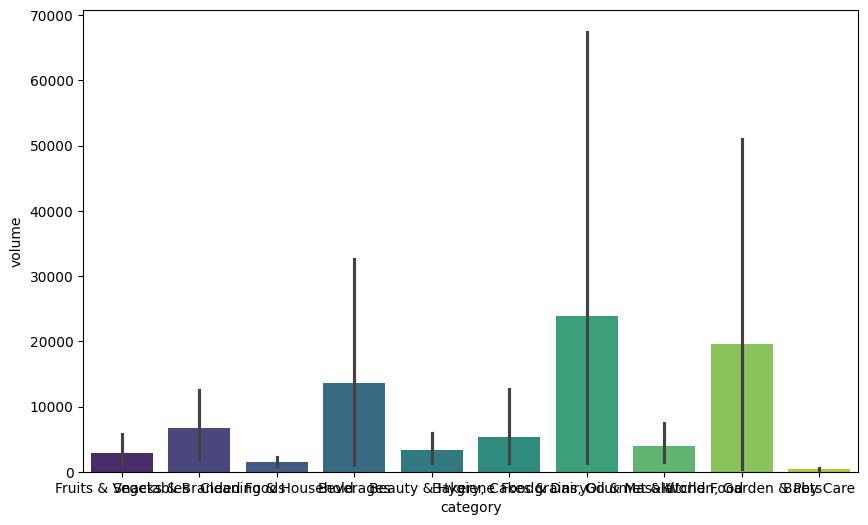

In [29]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x='category', y='volume', palette='viridis', data=df)


<Axes: xlabel='product_id'>

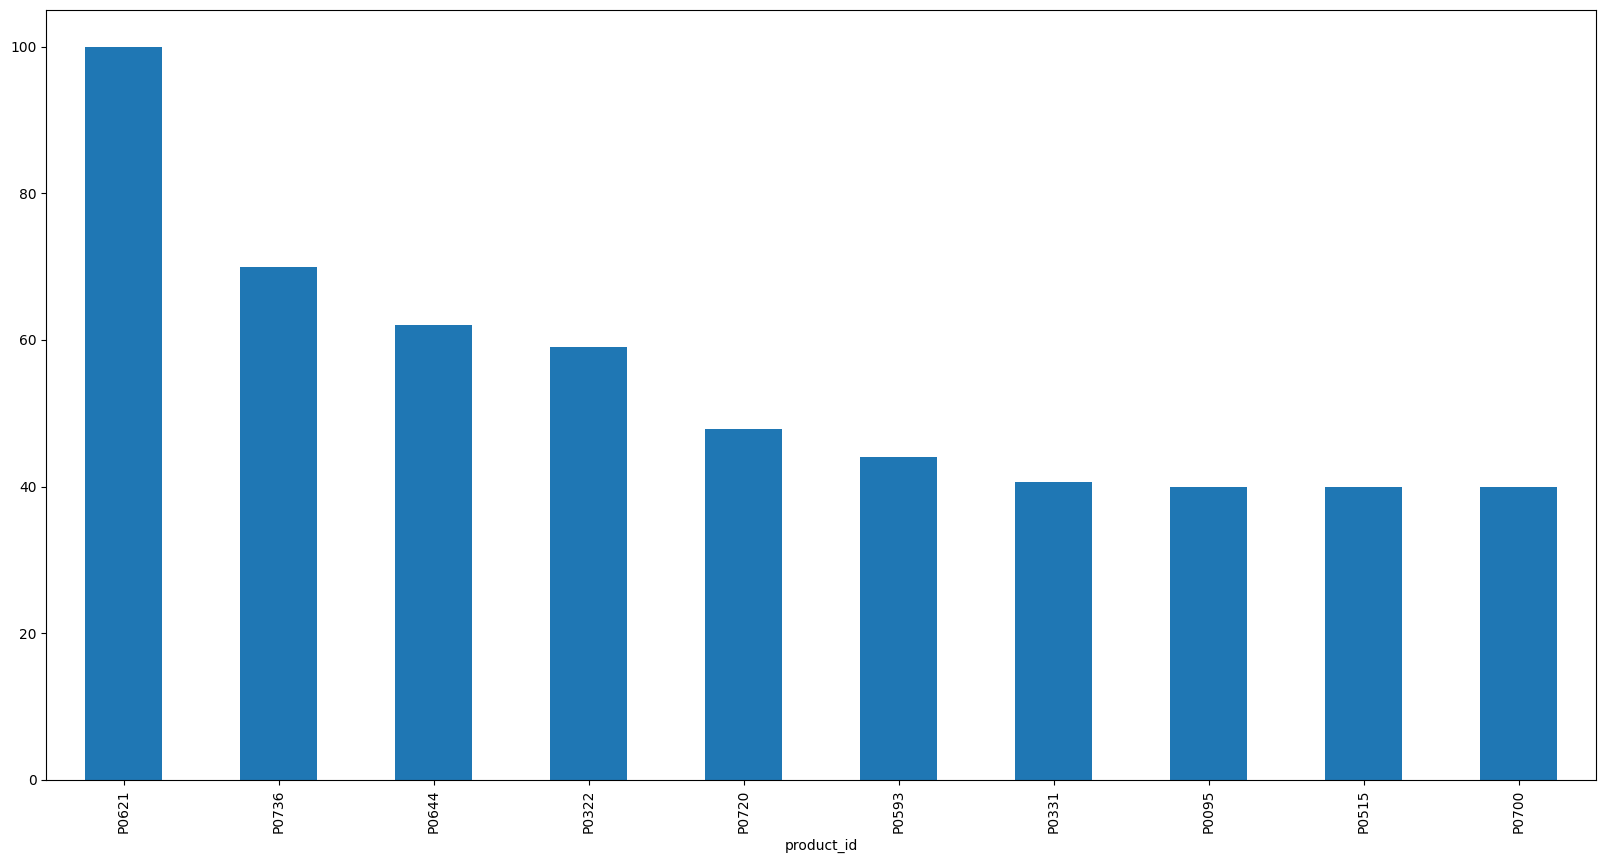

In [31]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('product_id')['length'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='brand'>

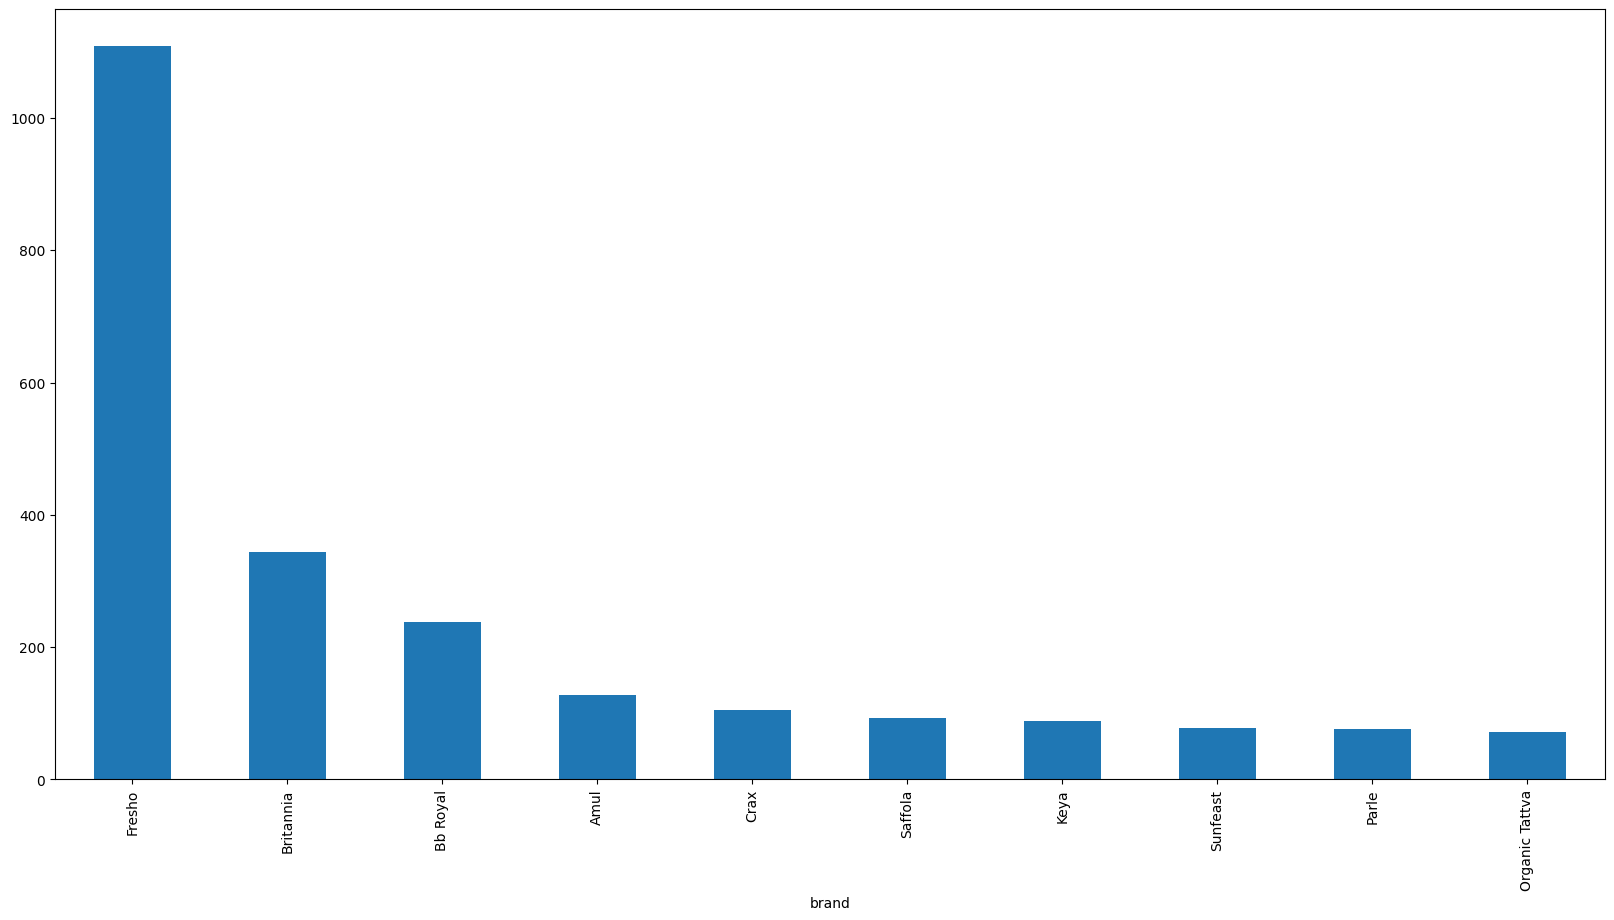

In [32]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('brand')['length'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='product'>

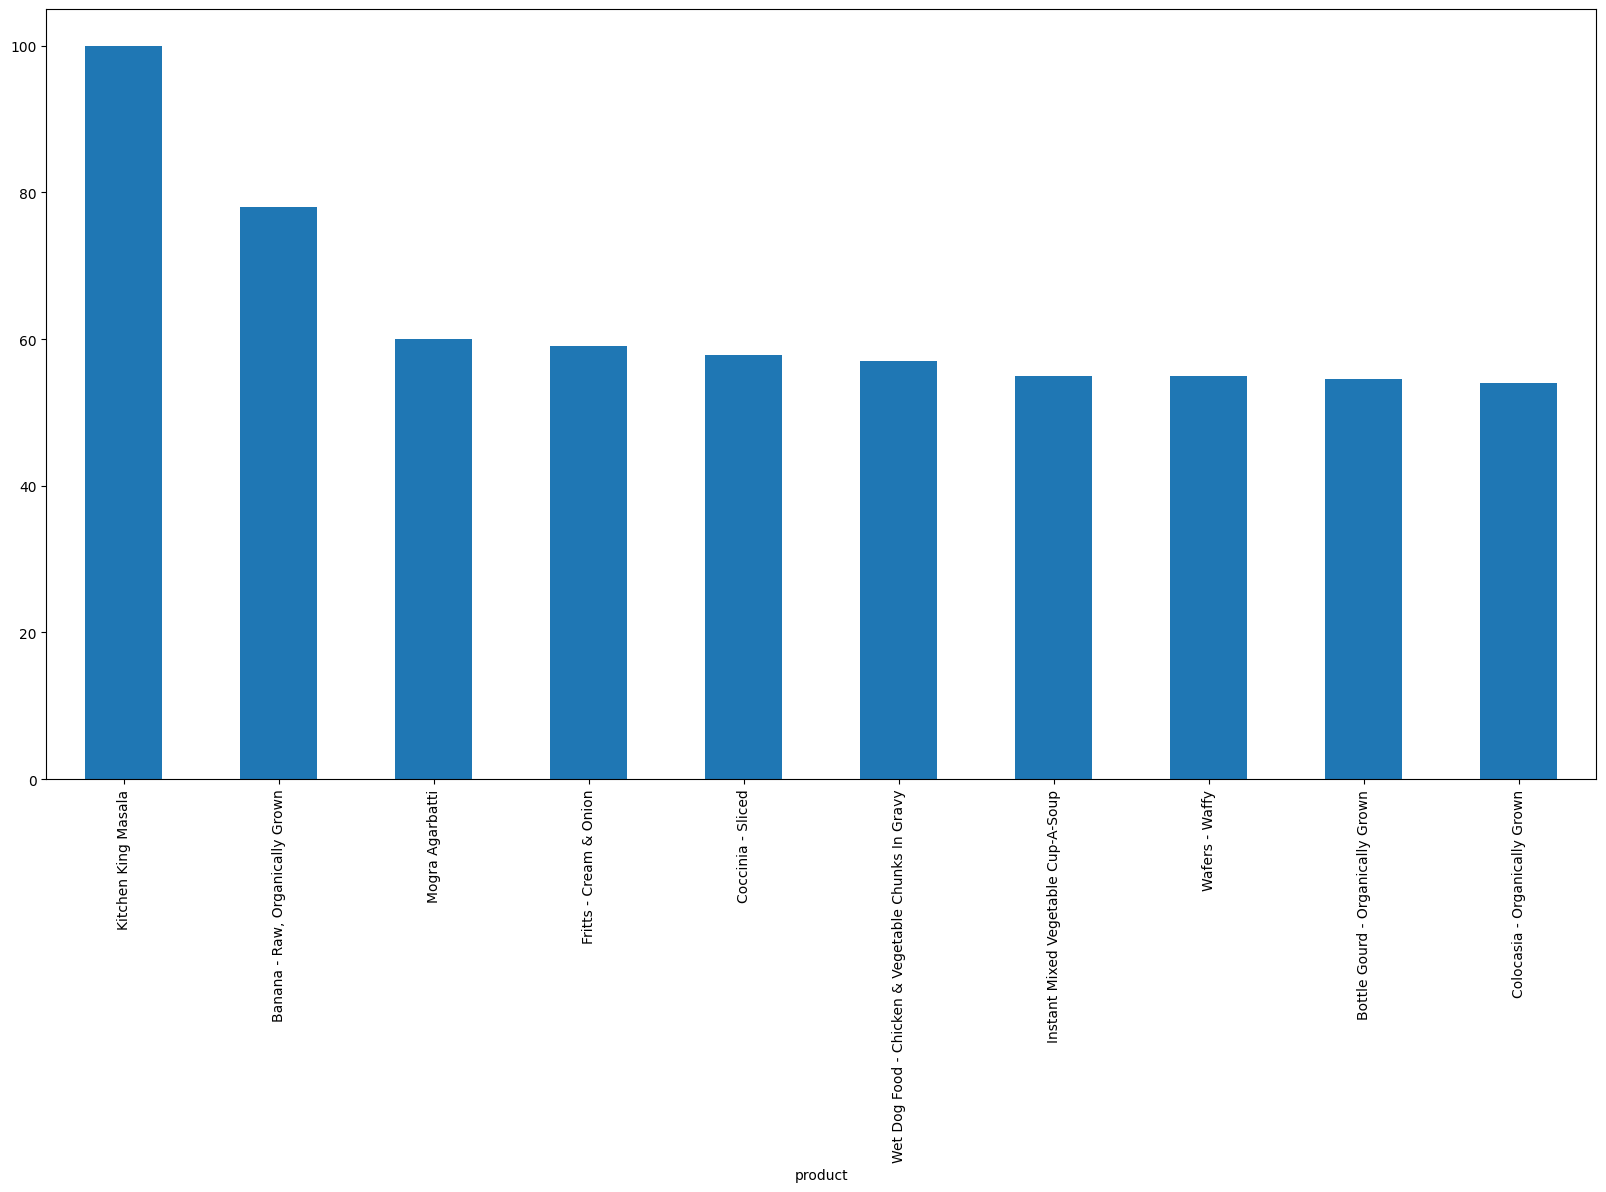

In [33]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('product')['width'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

In [38]:
df_filtered = df[df['type'] == 'organic veg']
df_filtered.to_csv('product.csv', index=False)
checked_df = pd.read_csv('product.csv')

In [40]:
original_types = df_filtered.dtypes.to_dict()
checked_df = pd.read_csv('product.csv', dtype=original_types)
pd.testing.assert_frame_equal(df_filtered, checked_df)